**Projeto Final de Ciência de Dados **— Tema 1: Cobertura vacinal e mortalidade infantil por região

**Kauã Guimarães Esperança Moreira**
**Samuel Souza Del Grande**

**Contexto:** a cobertura vacinal contra poliomielite varia consideravelmente 
entre os municípios brasileiros. Este trabalho investiga se essa variação se 
associa a diferenças nos indicadores de mortalidade, e se a mortalidade em si 
varia de forma consistente entre as regiões do país.

**Pergunta central:** existe relação entre a cobertura vacinal contra 
poliomielite e a taxa de mortalidade entre municípios e regiões brasileiras?
Fonte: Ministério da Saúde/DATASUS

**Link:** https://datasus.saude.gov.br/informacoes-de-saude-tabnet/

Importando bibliotecas

In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Carregando Dados

In [50]:
imunizacao = pd.read_csv(
    "ImunizaçãoPorMunicípio2022.csv",
    sep=";",
    encoding="latin1"
)

obitos = pd.read_csv(
    "ÓbitosPorMunicípio2022.csv",
    sep=";",
    encoding="latin1",
    skiprows=3
)

nascidos = pd.read_csv(
    "NascidosVivosPorMunicípio2022.csv",
    sep=";",
    encoding="latin1",
    skiprows=3
)



Verificando o que foi carregado

In [51]:
print("Imunização:", imunizacao.shape)
print("Óbitos:", obitos.shape)
print("Nascidos vivos:", nascidos.shape)

Imunização: (5570, 2)
Óbitos: (4078, 2)
Nascidos vivos: (5604, 2)


Colunas

In [52]:
print("COLUNAS - IMUNIZAÇÃO")
print(imunizacao.columns.tolist())

print("\nCOLUNAS - ÓBITOS")
print(obitos.columns.tolist())

print("\nCOLUNAS - NASCIDOS VIVOS")
print(nascidos.columns.tolist())

imunizacao.columns = ["Municipio", "Poliomielite"]
obitos.columns = ["Municipio", "Obitos"]
nascidos.columns = ["Municipio", "Nascidos_Vivos"]

print("COLUNAS - IMUNIZAÇÃO")
print(imunizacao.columns.tolist())

print("\nCOLUNAS - ÓBITOS")
print(obitos.columns.tolist())

print("\nCOLUNAS - NASCIDOS VIVOS")
print(nascidos.columns.tolist())



COLUNAS - IMUNIZAÇÃO
['Municï¿½pio', 'Poliomielite']

COLUNAS - ÓBITOS
['Municï¿½pio', 'ï¿½bitos_p/Residï¿½nc']

COLUNAS - NASCIDOS VIVOS
['Municï¿½pio', 'Nascim_p/resid.mï¿½e']
COLUNAS - IMUNIZAÇÃO
['Municipio', 'Poliomielite']

COLUNAS - ÓBITOS
['Municipio', 'Obitos']

COLUNAS - NASCIDOS VIVOS
['Municipio', 'Nascidos_Vivos']


Primeiros valores

In [53]:
display(imunizacao.head())
display(obitos.head())
display(nascidos.head())

,Municipio,Poliomielite
0,110001 ALTA FLORESTA D\'OESTE,"101,50"
1,110002 ARIQUEMES,"85,40"
2,110003 CABIXI,"97,10"
3,110004 CACOAL,"85,66"
4,110005 CEREJEIRAS,"95,17"


,Municipio,Obitos
0,110001 ALTA FLORESTA D'OESTE,2.0
1,110002 ARIQUEMES,32.0
2,110004 CACOAL,13.0
3,110005 CEREJEIRAS,1.0
4,110006 COLORADO DO OESTE,4.0


,Municipio,Nascidos_Vivos
0,MUNICIPIO IGNORADO - RO,2
1,110001 ALTA FLORESTA D'OESTE,368
2,110002 ARIQUEMES,1505
3,110003 CABIXI,64
4,110004 CACOAL,1353


In [54]:
imunizacao.info()
obitos.info()
nascidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Municipio     5570 non-null   str  
 1   Poliomielite  5570 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 4078 entries, 0 to 4077
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Municipio  4078 non-null   str    
 1   Obitos     4073 non-null   float64
dtypes: float64(1), str(1)
memory usage: 63.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 5604 entries, 0 to 5603
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Municipio       5604 non-null   str  
 1   Nascidos_Vivos  5599 non-null   str  
dtypes: str(2)
memory usage: 87.7 KB


In [55]:
print("ÓBITOS COM VALORES AUSENTES:")
display(obitos[obitos["Obitos"].isna()])

print("\nNASCIDOS VIVOS COM VALORES AUSENTES:")
display(nascidos[nascidos["Nascidos_Vivos"].isna()])

ÓBITOS COM VALORES AUSENTES:


,Municipio,Obitos
4073,Fonte: MS/SVSA/CGIAE - Sistema de Informaï¿½ï...,NaN
4074,Notas:,NaN
4075,Dados finais disponï¿½veis atï¿½ 2024 - data ...,NaN
4076,Dados de 2025 - Preliminares - data de extraï...,NaN
4077,Dados de 2026 - 1a prï¿½via - data de extraï¿...,NaN



NASCIDOS VIVOS COM VALORES AUSENTES:


,Municipio,Nascidos_Vivos
5599,Fonte: MS/SVSA/CGIAE - Sistema de Informaï¿½ï...,NaN
5600,Notas:,NaN
5601,Dados finais disponï¿½veis atï¿½ 2024 - data ...,NaN
5602,Dados de 2025 - Preliminares - data de extraï...,NaN
5603,Dados de 2026 - 1a prï¿½via - data de extraï¿...,NaN


In [56]:
print("ÓBITOS - ÚLTIMAS LINHAS")
display(obitos.tail(10))

print("\nNASCIDOS VIVOS - ÚLTIMAS LINHAS")
display(nascidos.tail(10))

print("\nIMUNIZAÇÃO - ÚLTIMAS LINHAS")
display(imunizacao.tail(10))

ÓBITOS - ÚLTIMAS LINHAS


,Municipio,Obitos
4068,522200 VIANOPOLIS,4.0
4069,522205 VICENTINOPOLIS,4.0
4070,522220 VILA BOA,1.0
4071,530010 BRASILIA,362.0
4072,Total,32257.0
4073,Fonte: MS/SVSA/CGIAE - Sistema de Informaï¿½ï...,NaN
4074,Notas:,NaN
4075,Dados finais disponï¿½veis atï¿½ 2024 - data ...,NaN
4076,Dados de 2025 - Preliminares - data de extraï...,NaN
4077,Dados de 2026 - 1a prï¿½via - data de extraï¿...,NaN



NASCIDOS VIVOS - ÚLTIMAS LINHAS


,Municipio,Nascidos_Vivos
5594,522220 VILA BOA,40
5595,522230 VILA PROPICIO,73
5596,530010 BRASILIA,35928
5597,000000 Ignorado ou exterior,-
5598,Total,2561922
5599,Fonte: MS/SVSA/CGIAE - Sistema de Informaï¿½ï...,NaN
5600,Notas:,NaN
5601,Dados finais disponï¿½veis atï¿½ 2024 - data ...,NaN
5602,Dados de 2025 - Preliminares - data de extraï...,NaN
5603,Dados de 2026 - 1a prï¿½via - data de extraï¿...,NaN



IMUNIZAÇÃO - ÚLTIMAS LINHAS


,Municipio,Poliomielite
5560,522170 URUANA,"87,41"
5561,522180 URUTAI,"95,83"
5562,522185 VALPARAISO DE GOIAS,"89,83"
5563,522190 VARJAO,"124,14"
5564,522200 VIANOPOLIS,"111,05"
5565,522205 VICENTINOPOLIS,"70,50"
5566,522220 VILA BOA,"137,25"
5567,522230 VILA PROPICIO,"94,34"
5568,530010 BRASILIA,"78,33"
5569,Total,"77,20"


In [57]:
print(imunizacao["Poliomielite"].head(20).to_list())

['101,50', '85,40', '97,10', '85,66', '95,17', '101,97', '101,87', '93,68', '89,17', '52,91', '84,87', '79,28', '83,96', '106,09', '78,83', '95,85', '72,47', '74,52', '102,08', '84,83']


Limpeza de "Imunização" e convertendo cobertura para numerico

In [58]:
imunizacao = imunizacao[
    imunizacao["Municipio"].str.match(r"^\d{6}\s", na=False)
].copy()

imunizacao["Poliomielite"] = (
    imunizacao["Poliomielite"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

Limpando óbitos

In [59]:
obitos = obitos[
    obitos["Municipio"].str.match(r"^\d{6}\s", na=False)
].copy()

obitos = obitos[
    obitos["Municipio"].str.match(r"^\d{6}\s", na=False)
].copy()

Limpando nascidos vivos

In [60]:
nascidos = nascidos[
    nascidos["Municipio"].str.match(r"^\d{6}\s", na=False)
].copy()

nascidos = nascidos[
    nascidos["Municipio"].str.match(r"^\d{6}\s", na=False)
].copy()

Criando código para os municípios (nova coluna)

In [61]:
imunizacao["codigo_municipio"] = imunizacao["Municipio"].str.extract(r"^(\d{6})")[0]

obitos["codigo_municipio"] = obitos["Municipio"].str.extract(r"^(\d{6})")[0]

nascidos["codigo_municipio"] = nascidos["Municipio"].str.extract(r"^(\d{6})")[0]

Cruzando dados

In [62]:
df = pd.merge(
    imunizacao[["codigo_municipio", "Municipio", "Poliomielite"]],
    obitos[["codigo_municipio", "Obitos"]],
    on="codigo_municipio",
    how="inner"
)

In [63]:
df = pd.merge(
    df,
    nascidos[["codigo_municipio", "Nascidos_Vivos"]],
    on="codigo_municipio",
    how="inner"
)

In [64]:
df = df.rename(columns={
    "Poliomielite": "Cobertura_Poliomielite",
    "Óbitos_p/Residênc": "Obitos",
    "Nascim_p/resid.mãe": "Nascidos_Vivos"
})

Criando a taxa de mortalidade

In [65]:
nascidos = nascidos[
    nascidos["codigo_municipio"] != "000000"
].copy()

In [66]:
nascidos["Nascim_p/resid.mãe"] = pd.to_numeric(
    nascidos["Nascidos_Vivos"],
    errors="coerce"
)

In [67]:
df["Nascidos_Vivos"] = pd.to_numeric(
    df["Nascidos_Vivos"],
    errors="coerce"
)

In [68]:
df["Taxa_Mortalidade"] = (
    df["Obitos"] /
    df["Nascidos_Vivos"]
) * 1000

Criando as regiões

In [69]:
uf_por_codigo = {
    "11": "RO",
    "12": "AC",
    "13": "AM",
    "14": "RR",
    "15": "PA",
    "16": "AP",
    "17": "TO",
    "21": "MA",
    "22": "PI",
    "23": "CE",
    "24": "RN",
    "25": "PB",
    "26": "PE",
    "27": "AL",
    "28": "SE",
    "29": "BA",
    "31": "MG",
    "32": "ES",
    "33": "RJ",
    "35": "SP",
    "41": "PR",
    "42": "SC",
    "43": "RS",
    "50": "MS",
    "51": "MT",
    "52": "GO",
    "53": "DF"
}

In [70]:
df["UF"] = df["codigo_municipio"].str[:2].map(uf_por_codigo)

In [71]:
regiao_por_uf = {
    "RO": "Norte",
    "AC": "Norte",
    "AM": "Norte",
    "RR": "Norte",
    "PA": "Norte",
    "AP": "Norte",
    "TO": "Norte",
    
    "MA": "Nordeste",
    "PI": "Nordeste",
    "CE": "Nordeste",
    "RN": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "AL": "Nordeste",
    "SE": "Nordeste",
    "BA": "Nordeste",
    
    "MG": "Sudeste",
    "ES": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",
    
    "PR": "Sul",
    "SC": "Sul",
    "RS": "Sul",
    
    "MS": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "DF": "Centro-Oeste"
}

df["Região"] = df["UF"].map(regiao_por_uf)

Tabela Final

In [72]:
df = df.rename(columns={
    "Poliomielite": "Cobertura_Poliomielite",
    "Óbitos_p/Residênc": "Obitos",
    "Nascim_p/resid.mãe": "Nascidos_Vivos"
})

In [73]:
df = df[
    [
        "codigo_municipio",
        "Municipio",
        "UF",
        "Região",
        "Cobertura_Poliomielite",
        "Obitos",
        "Nascidos_Vivos",
        "Taxa_Mortalidade"
    ]
]

Verificações :

In [74]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
display(df.describe())

(4062, 8)
codigo_municipio              str
Municipio                     str
UF                            str
Região                        str
Cobertura_Poliomielite    float64
Obitos                    float64
Nascidos_Vivos              int64
Taxa_Mortalidade          float64
dtype: object
codigo_municipio          0
Municipio                 0
UF                        0
Região                    0
Cobertura_Poliomielite    0
Obitos                    0
Nascidos_Vivos            0
Taxa_Mortalidade          0
dtype: int64


,Cobertura_Poliomielite,Obitos,Nascidos_Vivos,Taxa_Mortalidade
count,4062.000000,4062.000000,4062.000000,4062.000000
mean,89.872546,7.936238,607.124077,17.713380
std,22.029220,32.559133,2805.745772,12.782438
min,12.090000,1.000000,7.000000,1.562500
25%,76.905000,1.000000,100.000000,9.912674
50%,88.530000,3.000000,204.000000,14.285714
75%,101.740000,6.000000,445.750000,21.276596
max,316.000000,1437.000000,132050.000000,166.666667


Quantos municípios possuem cobertura acima de 100% e quantos têm poucos nascidos vivos

In [75]:
print("Cobertura acima de 100%:")
print((df["Cobertura_Poliomielite"] > 100).sum())

print("\nCobertura igual ou abaixo de 100%:")
print((df["Cobertura_Poliomielite"] <= 100).sum())

Cobertura acima de 100%:
1114

Cobertura igual ou abaixo de 100%:
2948


In [76]:
print("Municípios com menos de 50 nascidos vivos:")
print((df["Nascidos_Vivos"] < 50).sum())

print("\nMunicípios com menos de 100 nascidos vivos:")
print((df["Nascidos_Vivos"] < 100).sum())

Municípios com menos de 50 nascidos vivos:
361

Municípios com menos de 100 nascidos vivos:
1004


In [77]:
print("Maiores coberturas:")
display(
    df.nlargest(10, "Cobertura_Poliomielite")[
        ["Municipio", "Cobertura_Poliomielite"]
    ]
)
print("\nMaiores taxas de mortalidade:")
display(
    df.nlargest(10, "Taxa_Mortalidade")[
        ["Municipio", "Nascidos_Vivos", "Obitos", "Taxa_Mortalidade"]
    ]
)

Maiores coberturas:


,Municipio,Cobertura_Poliomielite
559,211195 SUCUPIRA DO RIACHAO,316.00
2130,313830 LEANDRO FERREIRA,235.00
1629,291330 ICHU,230.77
4003,521480 NOVA AURORA,228.57
3650,431673 SANTA CECILIA DO SUL,220.00
370,172097 TALISMA,208.70
534,211065 SAO DOMINGOS DO AZEITAO,200.00
1126,251365 JOCA CLAUDINO,192.86
3903,510885 NOVA MARILANDIA,181.82
2256,315300 PRATINHA,175.76



Maiores taxas de mortalidade:


,Municipio,Nascidos_Vivos,Obitos,Taxa_Mortalidade
3720,432255 VANINI,12,2.0,166.666667
3715,432235 UNIAO DA SERRA,7,1.0,142.857143
3322,420475 CUNHATAI,16,2.0,125.000000
4053,522157 UIRAPURU,35,4.0,114.285714
711,221037 SAO LUIS DO PIAUI,29,3.0,103.448276
2017,312460 ESTRELA DALVA,20,2.0,100.000000
3514,430511 CENTENARIO,20,2.0,100.000000
3703,432149 TOROPI,20,2.0,100.000000
3027,410315 BOM JESUS DO SUL,41,4.0,97.560976
590,220117 BARRA D\'ALCANTARA,42,4.0,95.238095


In [78]:
col = nascidos.columns[1]
print(repr(col))
print([hex(ord(c)) for c in col])

'Nascidos_Vivos'
['0x4e', '0x61', '0x73', '0x63', '0x69', '0x64', '0x6f', '0x73', '0x5f', '0x56', '0x69', '0x76', '0x6f', '0x73']


Estatística descritiva geral

In [79]:
display(
    df[
        [
            "Cobertura_Poliomielite",
            "Obitos",
            "Nascidos_Vivos",
            "Taxa_Mortalidade"
        ]
    ].describe()
)

,Cobertura_Poliomielite,Obitos,Nascidos_Vivos,Taxa_Mortalidade
count,4062.000000,4062.000000,4062.000000,4062.000000
mean,89.872546,7.936238,607.124077,17.713380
std,22.029220,32.559133,2805.745772,12.782438
min,12.090000,1.000000,7.000000,1.562500
25%,76.905000,1.000000,100.000000,9.912674
50%,88.530000,3.000000,204.000000,14.285714
75%,101.740000,6.000000,445.750000,21.276596
max,316.000000,1437.000000,132050.000000,166.666667


Estatística descritiva por região

In [80]:
resumo_regiao = df.groupby("Região").agg(
    Municipios=("codigo_municipio", "count"),
    
    Cobertura_Media=("Cobertura_Poliomielite", "mean"),
    Cobertura_Mediana=("Cobertura_Poliomielite", "median"),
    
    Mortalidade_Media=("Taxa_Mortalidade", "mean"),
    Mortalidade_Mediana=("Taxa_Mortalidade", "median")
)
display(resumo_regiao)

,Municipios,Cobertura_Media,Cobertura_Mediana,Mortalidade_Media,Mortalidade_Mediana
Região,,,,,
Centro-Oeste,334,92.852275,89.830,19.519657,14.285714
Nordeste,1476,91.323780,90.575,17.426092,14.803857
Norte,376,80.274521,80.215,18.005955,15.822351
Sudeste,1146,89.332731,87.685,16.996058,13.333333
Sul,730,91.366014,89.070,18.443221,13.932429


Cobertura vacinal distribuída entre as regiões

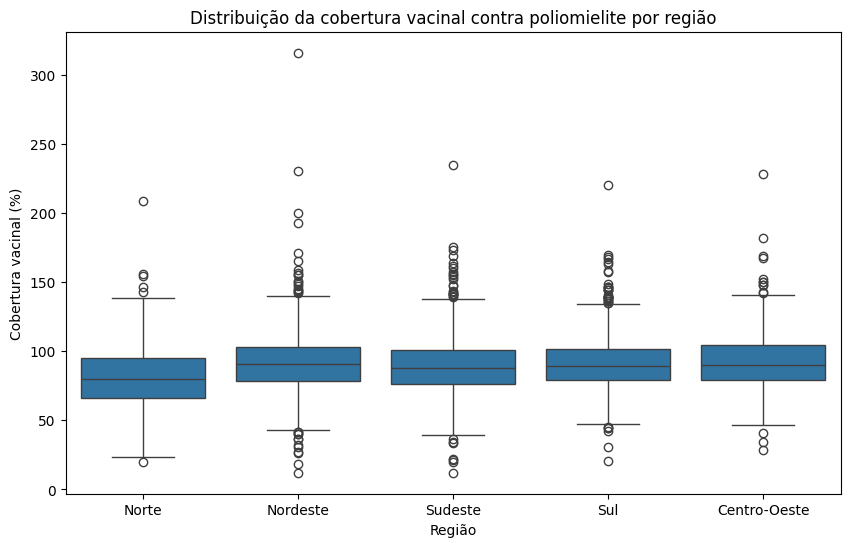

In [81]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Região",
    y="Cobertura_Poliomielite"
)
plt.title("Distribuição da cobertura vacinal contra poliomielite por região")
plt.xlabel("Região")
plt.ylabel("Cobertura vacinal (%)")

plt.show()

Mortalidade infantil distribuída entre as regiões

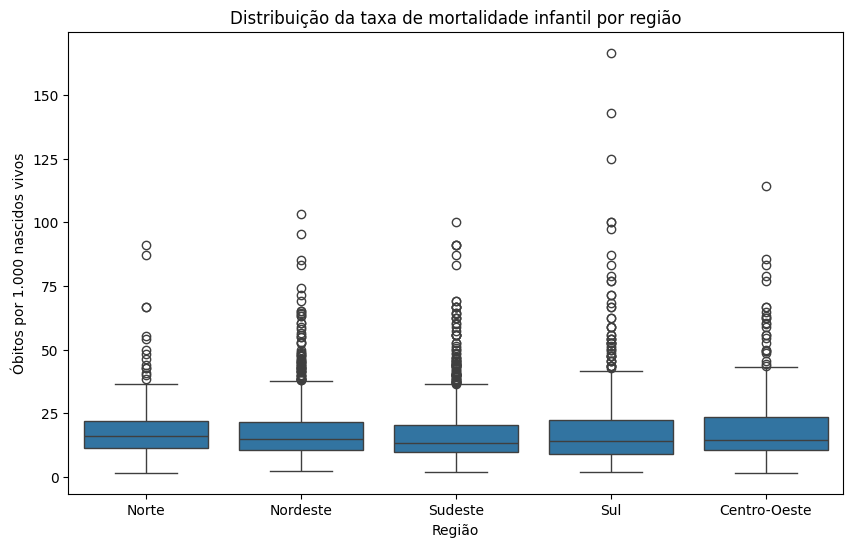

In [82]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Região",
    y="Taxa_Mortalidade"
)
plt.title("Distribuição da taxa de mortalidade infantil por região")
plt.xlabel("Região")
plt.ylabel("Óbitos por 1.000 nascidos vivos")

plt.show()

Investigando outliers

Cobertura > 100%

In [83]:
cobertura_acima_100 = df[
    df["Cobertura_Poliomielite"] > 100
]
print(
    "Municípios com cobertura acima de 100%:",
    len(cobertura_acima_100)
)
print(
    "Percentual:",
    round(len(cobertura_acima_100) / len(df) * 100, 2),
    "%"
)

Municípios com cobertura acima de 100%: 1114
Percentual: 27.42 %


Concentração por região

In [84]:
display(
    df.groupby("Região").apply(
        lambda x: (x["Cobertura_Poliomielite"] > 100).sum()
    )
)

Região
Centro-Oeste    107
Nordeste        444
Norte            64
Sudeste         306
Sul             193
dtype: int64

Investigando municípios pequenos

In [85]:
print(
    "Municípios com menos de 50 nascidos vivos:",
    (df["Nascidos_Vivos"] < 50).sum()
)
print(
    "Municípios com menos de 100 nascidos vivos:",
    (df["Nascidos_Vivos"] < 100).sum()
)

Municípios com menos de 50 nascidos vivos: 361
Municípios com menos de 100 nascidos vivos: 1004


Vacinação X Mortalidade

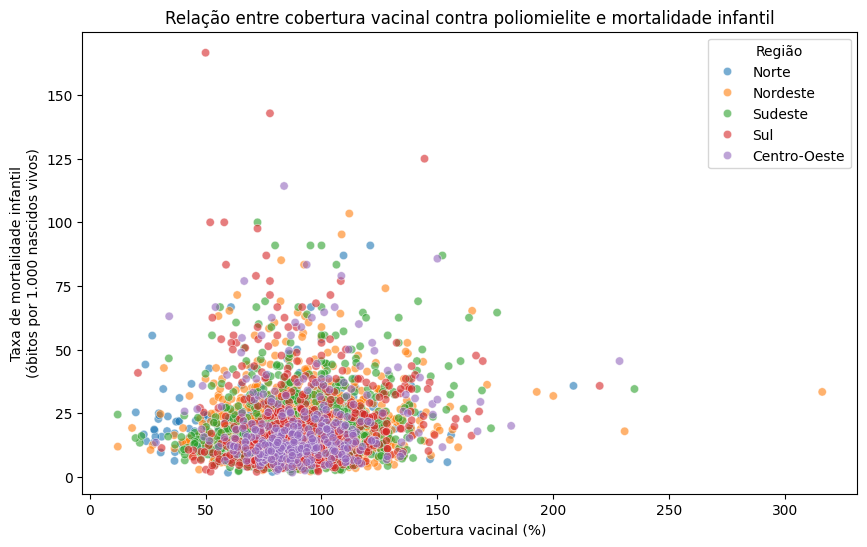

In [86]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Cobertura_Poliomielite",
    y="Taxa_Mortalidade",
    hue="Região",
    alpha=0.6
)
plt.title(
    "Relação entre cobertura vacinal contra poliomielite e mortalidade infantil"
)
plt.xlabel("Cobertura vacinal (%)")
plt.ylabel("Taxa de mortalidade infantil\n(óbitos por 1.000 nascidos vivos)")

plt.show()

Distribuição da taxa de mortalidade por quantidade de municípios

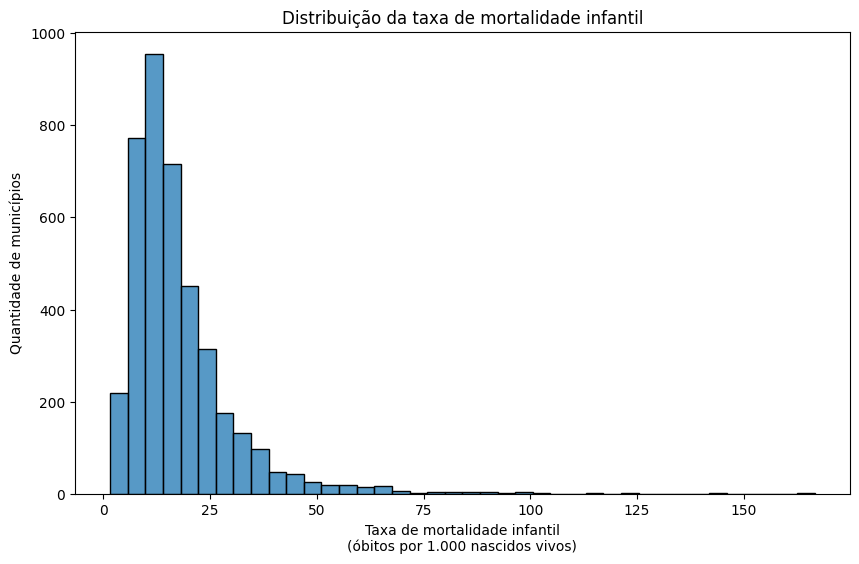

In [87]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Taxa_Mortalidade",
    bins=40
)
plt.title("Distribuição da taxa de mortalidade infantil")
plt.xlabel("Taxa de mortalidade infantil\n(óbitos por 1.000 nascidos vivos)")
plt.ylabel("Quantidade de municípios")
plt.show()

Comparando média e mediana

In [88]:
comparacao = df.groupby("Região").agg(
    Cobertura_Media=("Cobertura_Poliomielite", "mean"),
    Cobertura_Mediana=("Cobertura_Poliomielite", "median"),
    Mortalidade_Media=("Taxa_Mortalidade", "mean"),
    Mortalidade_Mediana=("Taxa_Mortalidade", "median")
)
display(comparacao)

,Cobertura_Media,Cobertura_Mediana,Mortalidade_Media,Mortalidade_Mediana
Região,,,,
Centro-Oeste,92.852275,89.830,19.519657,14.285714
Nordeste,91.323780,90.575,17.426092,14.803857
Norte,80.274521,80.215,18.005955,15.822351
Sudeste,89.332731,87.685,16.996058,13.333333
Sul,91.366014,89.070,18.443221,13.932429


Distribuição da cobertura vacinal por região

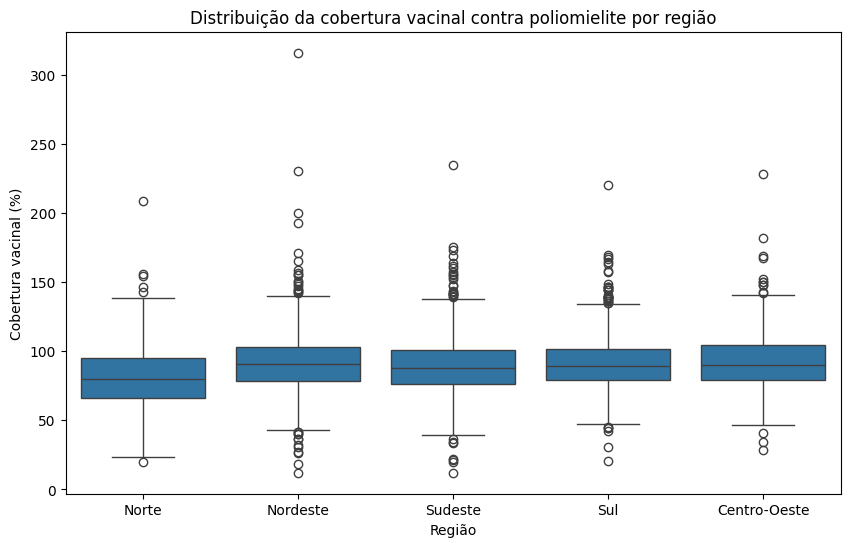

In [89]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Região",
    y="Cobertura_Poliomielite"
)

plt.title("Distribuição da cobertura vacinal contra poliomielite por região")
plt.xlabel("Região")
plt.ylabel("Cobertura vacinal (%)")

plt.show()

Distribuição da mortalidade infantil por região

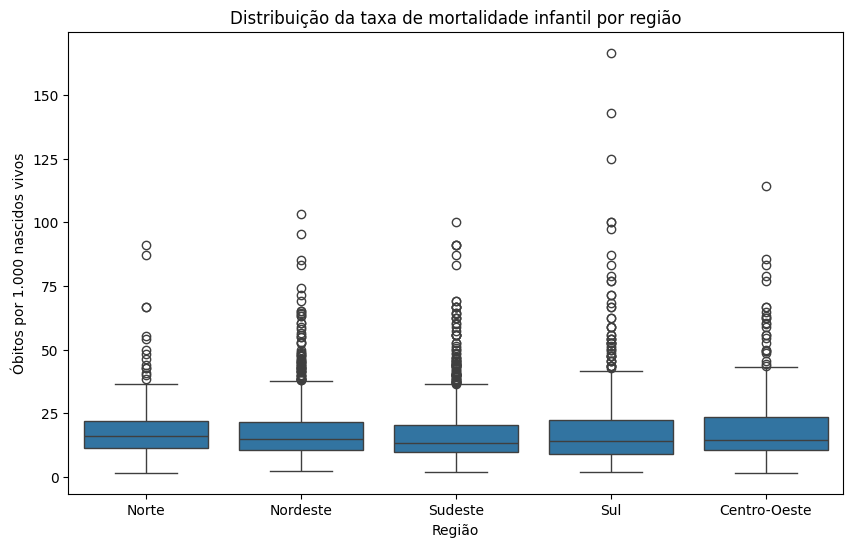

In [90]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Região",
    y="Taxa_Mortalidade"
)

plt.title("Distribuição da taxa de mortalidade infantil por região")
plt.xlabel("Região")
plt.ylabel("Óbitos por 1.000 nascidos vivos")

plt.show()

Correlação entre vacinação e mortalidade

In [91]:
from scipy.stats import spearmanr

correlacao, p_valor = spearmanr(
    df["Cobertura_Poliomielite"],
    df["Taxa_Mortalidade"]
)

print("Correlação de Spearman:", correlacao)
print("p-valor:", p_valor)

Correlação de Spearman: 0.08474871108973966
p-valor: 6.322546299109936e-08


In [92]:
from scipy.stats import kruskal

grupos = [
    grupo["Taxa_Mortalidade"].values
    for _, grupo in df.groupby("Região")
]

estatistica, p_valor = kruskal(*grupos)

print("Estatística de Kruskal-Wallis:", estatistica)
print("p-valor:", p_valor)

Estatística de Kruskal-Wallis: 25.292453277852367
p-valor: 4.393656836676352e-05


Análise pós-teste em pares

In [93]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

regioes = df["Região"].unique()

resultados = []

for regiao1, regiao2 in combinations(regioes, 2):
    grupo1 = df[df["Região"] == regiao1]["Taxa_Mortalidade"]
    grupo2 = df[df["Região"] == regiao2]["Taxa_Mortalidade"]

    estatistica, p_valor = mannwhitneyu(
        grupo1,
        grupo2,
        alternative="two-sided"
    )

    resultados.append({
        "Região 1": regiao1,
        "Região 2": regiao2,
        "U": estatistica,
        "p_valor": p_valor
    })

resultados_posthoc = pd.DataFrame(resultados)

resultados_posthoc["p_valor_ajustado"] = multipletests(
    resultados_posthoc["p_valor"],
    method="holm"
)[1]

resultados_posthoc["Significativo"] = (
    resultados_posthoc["p_valor_ajustado"] < 0.05
)

display(resultados_posthoc)

,Região 1,Região 2,U,p_valor,p_valor_ajustado,Significativo
0,Norte,Nordeste,292959.0,0.094687,0.378750,False
1,Norte,Sudeste,245544.0,0.000047,0.000471,True
2,Norte,Sul,151391.5,0.004920,0.039360,True
3,Norte,Centro-Oeste,65112.0,0.395145,1.000000,False
4,Nordeste,Sudeste,918608.0,0.000151,0.001360,True
5,Nordeste,Sul,569945.0,0.026645,0.159868,False
6,Nordeste,Centro-Oeste,243015.5,0.686954,1.000000,False
7,Sudeste,Sul,410344.0,0.487313,1.000000,False
8,Sudeste,Centro-Oeste,173413.0,0.008940,0.062581,False
9,Sul,Centro-Oeste,113491.5,0.070351,0.351756,False


Análise de sensibilidade

In [94]:
df_sensibilidade = df[df["Nascidos_Vivos"] >= 100].copy()

correlacao_sens, p_valor_sens = spearmanr(
    df_sensibilidade["Cobertura_Poliomielite"],
    df_sensibilidade["Taxa_Mortalidade"]
)
print("Municípios na análise de sensibilidade:", len(df_sensibilidade))
print("Correlação de Spearman:", correlacao_sens)
print("p-valor:", p_valor_sens)

Municípios na análise de sensibilidade: 3058
Correlação de Spearman: -0.022333253393548212
p-valor: 0.21695714419389503


Conclusão

A análise dos dados de 2022 mostrou diferenças na cobertura vacinal contra poliomielite e na taxa de mortalidade infantil entre as regiões brasileiras. A correlação de Spearman apontou uma associação positiva, mas muito fraca, entre as duas variáveis. O teste de Kruskal-Wallis também apontou diferenças estatisticamente significativas na distribuição da mortalidade entre algumas regiões. Porém, na análise de sensibilidade considerando apenas municípios com pelo menos 100 nascidos vivos, a correlação deixou de ser significativa. Dessa forma, os resultados não indicam uma relação forte entre a cobertura vacinal e a mortalidade infantil no período de 2022, sendo necessário considerar as limitações dos dados, principalmente as taxas em municípios com poucos nascidos vivos, que se mostrou bem instável, .

A análise dos dados de 2022 mostrou diferenças na cobertura vacinal contra poliomielite e na taxa de mortalidade infantil entre os municípios e regiões brasileiras. Na base completa, o teste de Spearman encontrou uma correlação positiva, porém muito fraca, entre cobertura vacinal e mortalidade (ρ = 0,085; p < 0,001). Quando consideramos apenas municípios com pelo menos 100 nascidos vivos, essa correlação passou para ρ = -0,022 e deixou de ser significativa (p = 0,22), mostrando que o resultado inicial é bastante sensível aos municípios com poucos nascimentos. Por outro lado, o teste de Kruskal-Wallis indicou diferenças significativas na distribuição da mortalidade entre as regiões (p < 0,001), com os testes posteriores apontando diferenças principalmente entre Norte e Sudeste, Norte e Sul, e Nordeste e Sudeste. Dessa forma, os dados analisados não apresentam evidências de uma relação tão forte entre a cobertura vacinal contra poliomielite e a mortalidade infantil neste recorte, enquanto as diferenças regionais de mortalidade aparecem de forma mais consistente. Esses resultados indicam que outros fatores, como condições socioeconômicas, acesso aos serviços de saúde e saneamento, podem ser importantes para compreender as diferenças observadas, mesmo que não tenham sido avaliados diretamente neste trabalho. Além disso, deve-se considerar a limitação relacionada aos municípios com poucos nascidos vivos, que podem apresentar taxas de mortalidade mais instáveis, e à própria definição da variável de óbitos utilizada na base.